In [1]:
from pyeed.core import ProteinRecord
from pathlib import Path
from rich.progress import Progress
import numpy as np
from pyeed.align import MSA
from transformers import BertModel, BertTokenizer
import torch
import re


from pyeed.align import AbstractAligner
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

## Get Data

In [2]:
blast = False

if blast:
    mat = ProteinRecord.get_id("Q00266")
    cvt = ProteinRecord.get_id("P0A749")

    mats = mat.ncbi_blast(n_hits=1000)
    cvts = cvt.ncbi_blast(n_hits=1000)

    for m in mats:
    m.name = "mat"

    for c in cvts:
        c.name = "cvt"

    seqs = [*mats, *cvts]

    for seq in seqs:
        with open(f"{seq.id}.json", "w") as f:
            f.write(seq.json())

else:
    seqs = [ProteinRecord.from_json(f) for f in Path(".").glob("*.json")]

Output()

In [3]:
a = [1,2,3]
a.extend([4,5,6])

a

[1, 2, 3, 4, 5, 6]

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    print("MPS device not found.")


tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert")
model.to(device)


def preprocess_sequence(sequence):
    sequence = re.sub(r"[UZOB]", "X", sequence)
    sequence = " ".join(sequence)
    return sequence


# Function to get embeddings
def get_embeddings(sequences, batch_size=64):
    progress = Progress()
    all_embeddings = []

    with progress as prog:
        for i in prog.track(range(0, len(sequences), batch_size)):
            batch = sequences[i : i + batch_size]
            preprocessed_batch = [preprocess_sequence(seq) for seq in batch]
            encoded_input = tokenizer(
                preprocessed_batch, return_tensors="pt", padding=True, truncation=True
            ).to(device)
            with torch.no_grad():
                output = model(**encoded_input)
            embeddings = output.last_hidden_state.mean(
                dim=1
            )  # Average the token embeddings to get the sequence embedding
            all_embeddings.append(embeddings)
        return torch.cat(all_embeddings)

In [5]:
embs = get_embeddings([se.sequence for se in seqs])

NameError: name 'seqs' is not defined

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from rich.progress import Progress


# Load the pre-trained model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("Rostlab/prot_bert_bfd", do_lower_case=False)
model = AutoModel.from_pretrained("Rostlab/prot_bert_bfd")


# Function to get embeddings for a list of protein sequences
def get_protein_embeddings(sequences):
    embeddings = []
    with Progress() as prog:
        for seq in prog.track(sequences):
            inputs = tokenizer(seq, return_tensors="pt", padding=True, truncation=True)
            with torch.no_grad():
                outputs = model(**inputs)
            # Mean pooling over the token embeddings
            seq_embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings.append(seq_embeddings.squeeze().numpy())
        return np.array(embeddings)


# Example sequences
sequences = [seq.sequence for seq in seqs]  # Replace with your 1000 sequences
embeddings = get_protein_embeddings(sequences)

Output()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
embeddings.shape

(592, 1024)

In [ ]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=0, verbose=1)

# Fit and transform data
X_2d = tsne.fit_transform(embs)

# map virides color map to the data
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=np.arange(len(X_2d)), cmap="viridis")

# plt.scatter(X_2d[:, 0], X_2d[:, 1], )
plt.savefig("plots/tsne.png")
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 592 samples in 0.001s...
[t-SNE] Computed neighbors for 592 samples in 0.149s...
[t-SNE] Computed conditional probabilities for sample 592 / 592
[t-SNE] Mean sigma: 0.281469
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.555424
[t-SNE] KL divergence after 1000 iterations: 0.335406


NameError: name 'np' is not defined

In [ ]:
import torch
import numpy as np

from transformers import BertModel, BertTokenizer

device = torch.device("mps")


tokenizer = BertTokenizer.from_pretrained(
    "Rostlab/prot_bert",
    do_lower_case=False,
)

model = BertModel.from_pretrained("Rostlab/prot_bert")

for i, sequence in track(enumerate(seqs)):
    encoded_input = tokenizer(sequence.sequence, return_tensors="pt")
    output = model(**encoded_input)

    # Save pooler output to numpy file
    hidden_states = output.last_hidden_state.detach().numpy()
    # vec = output.pooler_output.detach().numpy()
    vec = np.mean(hidden_states, axis=1)

    # Save vector to file
    np.save(f"{i}.npy", vec)

Output()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Load data from vectors and create a numpy array
data = []
for path in Path(".").rglob("*.npy"):
    data.append(np.load(path))

data = np.squeeze((np.array(data)))
data.shape

(592, 1024)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 592 samples in 0.001s...
[t-SNE] Computed neighbors for 592 samples in 0.046s...
[t-SNE] Computed conditional probabilities for sample 592 / 592
[t-SNE] Mean sigma: 0.281469
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.555424
[t-SNE] KL divergence after 1000 iterations: 0.335406


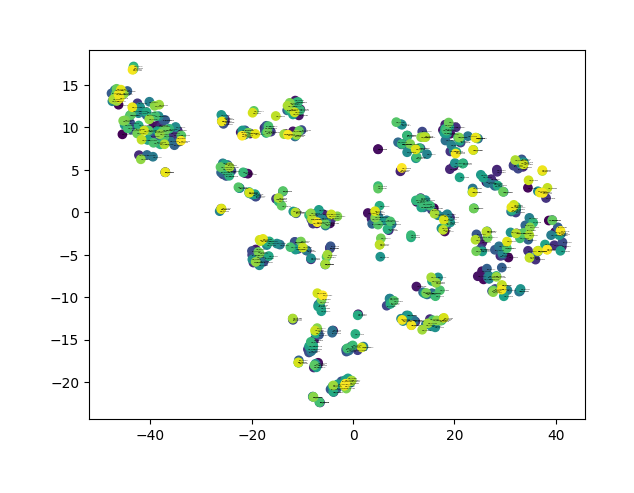

In [ ]:
# Perform t-SNE
tsne = TSNE(n_components=2, random_state=0, verbose=1)

# Fit and transform data
X_2d = tsne.fit_transform(embs)

# map virides color map to the data
lables = [se.id for se in seqs]
plt.scatter(
    X_2d[:, 0], X_2d[:, 1], c=np.arange(len(X_2d)), cmap="viridis", label=lables
)
# plot lables on the plot
for i, txt in enumerate(lables):
    plt.annotate(txt, (X_2d[i, 0], X_2d[i, 1]), fontsize=1)

# plt.scatter(X_2d[:, 0], X_2d[:, 1], )
plt.savefig("plots/tsne.png")
plt.show()


# the same in plotly...
import plotly.express as px
import pandas as pd

df = pd.DataFrame(X_2d, columns=["x", "y"])
df["labels"] = lables
df["colors"] = np.arange(len(X_2d))

fig = px.scatter(df, x="x", y="y", color="colors", hover_data=["labels"])
fig.show(dpi=300)

Output()

✅ Alignment completed


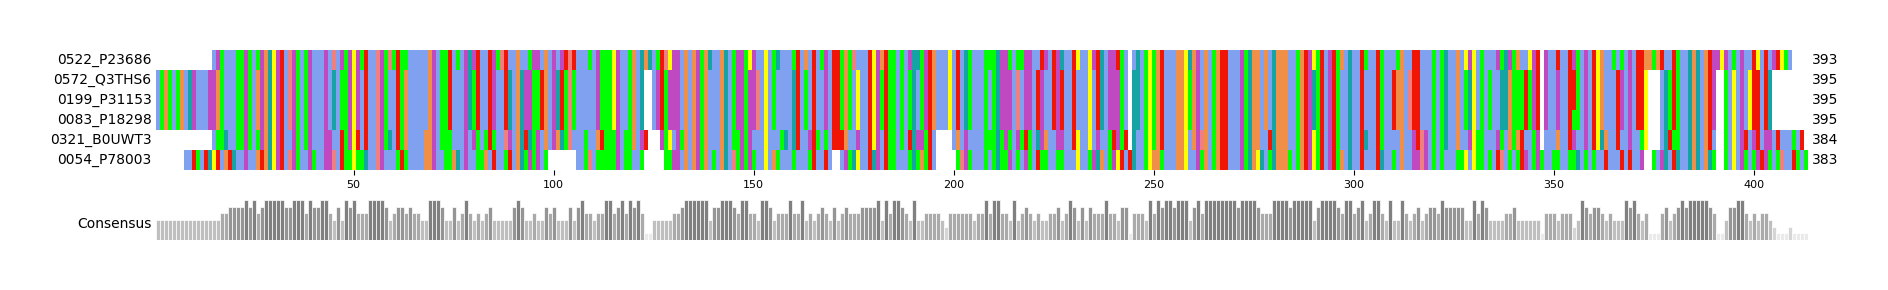

In [ ]:
cluster_ids = [
    "0199_P31153",
    "0083_P18298",
    "0572_Q3THS6",
    "0522_P23686",
    "0321_B0UWT3",
    "0054_P78003",
]

# get sequences with the cluster ids
cluster_seqs = [se for se in seqs if se.id in cluster_ids]

alignment = MSA(sequences=cluster_seqs).clustalo()
alignment.visualize()

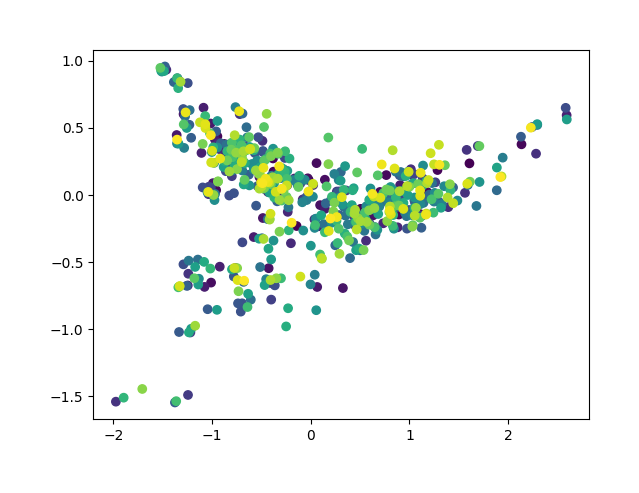

In [ ]:
from sklearn.decomposition import PCA


# Perform pca
pca = PCA(n_components=2)

# Fit and transform data
X_2d = pca.fit_transform(embs)

# Plot data

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=np.arange(len(X_2d)), cmap="viridis")
plt.savefig("plots/pca.png")
plt.show()

In [ ]:
X_2d[:, 0]

array([-1.6367305e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
       -1.6367336e-05, -1.6367336e-05, -1.6367336e-05, -1.6367336e-05,
      

In [ ]:
from transformers import BertModel, BertTokenizer
import torch

# Check if MPS is available, otherwise fall back to CPU

# Load the ProtBERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)

model = BertModel.from_pretrained("Rostlab/prot_bert")

In [ ]:
encoded_input = tokenizer(p.sequence, return_tensors="pt")
output = model(**encoded_input)

In [ ]:
output

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.1096,  0.0474, -0.0857,  ..., -0.0035, -0.0569,  0.0918],
         [-0.0628,  0.0624, -0.0855,  ...,  0.0178, -0.0978,  0.0628],
         [-0.1252,  0.0657, -0.1055,  ..., -0.0381,  0.0185,  0.0819]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-0.1668,  0.1769, -0.1581,  ...,  0.1679,  0.1562, -0.1718]],
       grad_fn=<TanhBackward0>), hidden_states=None, past_key_values=None, attentions=None, cross_attentions=None)

In [ ]:
output.last_hidden_state.shape

torch.Size([1, 3, 1024])

device(type='mps')